# 03 · Anomaly detection: finding faults before the fault code

**Question:** can a model trained only on normal driving detect the injected faults, point to the right subsystem, and do it before the ECU sets a fault code?

**Model:** one detector per subsystem (engine, speed, fuel, air, battery). Each combines an **Isolation Forest** with a simple **range score**, and an alarm is raised only when the anomaly persists. This notebook explains each choice and measures its effect.

**Contents**
1. Train the detector
2. Features: what each detector looks at
3. Why Isolation Forest alone is not enough
4. Ablation: forest only vs range only vs combined
5. Results per fault
6. How early is the warning?
7. Alarm persistence trade-off
8. One trip, step by step
9. Limitations and summary

> Same data and settings as `scripts/train_model.py`. Requires `python scripts/download_ved.py --weeks 1` and `python scripts/prepare_ved.py --weeks 1`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "analyzer").exists())
sys.path.insert(0, str(ROOT / "src"))

from analyzer.config import PROCESSED_DIR
from analyzer.detection.anomaly import AnomalyDetector
from analyzer.detection.evaluate import row_metrics, summarize, trip_results
from analyzer.features.engineering import FEATURE_GROUPS, build_features
from analyzer.synthetic.generator import NO_FAULT, generate

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
FAULT_SHADE, BAND = "#d03b3b", "#cde2fb"
TEXT, TEXT_2, GRID, MUTED = "#0b0b0b", "#52514e", "#e8e7e3", "#a3a29d"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": TEXT_2, "axes.titlecolor": TEXT,
    "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": TEXT_2, "ytick.color": TEXT_2, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "lines.linewidth": 2, "legend.frameon": False, "font.size": 10,
})
pd.set_option("display.float_format", "{:,.2f}".format)
TRIP = ["vehicle_id", "trip_id"]
FAULT_ORDER = ["vacuum_leak", "maf_drift", "rich_injector", "misfire", "speed_sensor_failure", "hv_battery_degradation"]

## 1. Train the detector

Training uses only normal VED trips that are **not** part of the synthetic dataset, so no evaluation trip (normal or faulty) is ever seen during training.

In [2]:
clean = pd.read_parquet(PROCESSED_DIR / "ved_clean.parquet")
data = generate(clean, n_faulty=120, n_normal=120, seed=42)
logs, labels = data.logs, data.labels

eval_keys = set(zip(labels["vehicle_id"], labels["trip_id"]))
in_eval = pd.Series([k in eval_keys for k in zip(clean["vehicle_id"], clean["trip_id"])], index=clean.index)
train = clean[~in_eval]

detector = AnomalyDetector().fit(train)
scored = detector.score(logs)

print(f"training: {train.groupby(TRIP).ngroups} normal trips, {len(train):,} readings")
print(f"evaluation: {len(labels)} trips ({(labels['fault'] == NO_FAULT).sum()} normal, "
      f"{(labels['fault'] != NO_FAULT).sum()} faulty), {len(logs):,} readings")
print(f"detectors trained: {', '.join(detector.models)}")

training: 609 normal trips, 350,114 readings
evaluation: 240 trips (120 normal, 120 faulty), 138,543 readings
detectors trained: engine, speed, fuel, air, battery


## 2. Features: what each detector looks at

Features measure **deviation from normal**, not raw values, so ordinary but less common driving (a highway run) is not mistaken for a fault. Airflow, battery voltage and fuel trims are compared with **each vehicle's own baseline**, learned from its normal trips (notebook 1 showed why). All features are computed over a rolling 60-reading window (about a minute).

In [3]:
DESCRIPTIONS = {
    "rpm_jitter_steady": "RPM jumpiness while speed is steady (misfire makes RPM jump at constant speed)",
    "rpm_dip_rate": "share of sudden RPM drops (> 150 rpm) at steady speed",
    "speed_jump_rate": "share of physically impossible speed changes (> 15 km/h per second)",
    "speed_zero_while_revving": "share of readings where speed drops to 0 right after moving, with RPM > 1000",
    "stft_rel_median": "short-term fuel trim minus this vehicle's usual level",
    "ltft_rel_median": "long-term fuel trim minus this vehicle's usual level",
    "total_trim_rel_median": "total fuel trim minus this vehicle's usual level",
    "maf_residual_median": "airflow vs expected from RPM x load for this engine (%)",
    "hv_voltage_residual_median": "battery voltage vs expected from charge level and current (V)",
    "hv_voltage_residual_min": "lowest of the above in the window (V)",
}
pd.DataFrame([{"detector": g, "feature": f, "meaning": DESCRIPTIONS[f]}
              for g, cols in FEATURE_GROUPS.items() for f in cols]).set_index(["detector", "feature"])

meaning
detector feature                                                                      
engine   rpm_jitter_steady           RPM jumpiness while speed is steady (misfire m...
         rpm_dip_rate                share of sudden RPM drops (> 150 rpm) at stead...
speed    speed_jump_rate             share of physically impossible speed changes (...
         speed_zero_while_revving    share of readings where speed drops to 0 right...
fuel     stft_rel_median             short-term fuel trim minus this vehicle's usua...
         ltft_rel_median             long-term fuel trim minus this vehicle's usual...
         total_trim_rel_median        total fuel trim minus this vehicle's usual level
air      maf_residual_median         airflow vs expected from RPM x load for this e...
battery  hv_voltage_residual_median  battery voltage vs expected from charge level ...
         hv_voltage_residual_min                 lowest of the above in the window (V)

The key feature of each fault, for normal trips vs the fully developed fault. Unlike notebook 2, these are the features the model actually sees, measured against each vehicle's baseline.

,feature,normal median,normal 1%-99%,full fault median
fault,,,,
vacuum_leak,total_trim_rel_median,1.56,-8.59 to 8.59,18.42
maf_drift,maf_residual_median,-0.27,-36.61 to 13.15,-42.10
rich_injector,total_trim_rel_median,1.56,-8.59 to 8.59,-19.76
misfire,rpm_jitter_steady,34.00,2.00 to 470.50,367.44
speed_sensor_failure,speed_zero_while_revving,0.00,0.00 to 0.00,0.12
hv_battery_degradation,hv_voltage_residual_median,-0.46,-13.37 to 18.03,-24.40


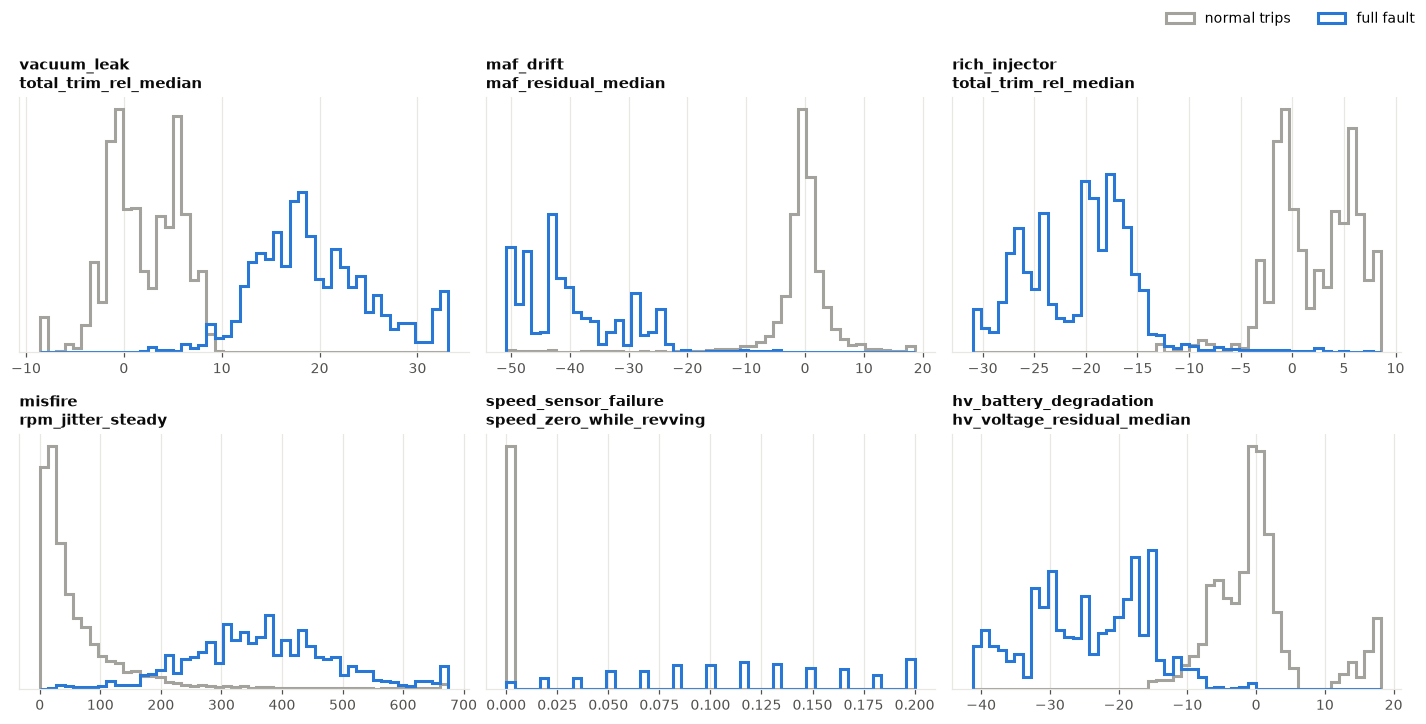

In [4]:
eval_df = scored.merge(logs[TRIP + ["time_ms", "fault", "fault_intensity"]], on=TRIP + ["time_ms"])
normal_rows = eval_df[eval_df["fault"] == NO_FAULT]
KEY_FEATURE = {
    "vacuum_leak": "total_trim_rel_median", "maf_drift": "maf_residual_median",
    "rich_injector": "total_trim_rel_median", "misfire": "rpm_jitter_steady",
    "speed_sensor_failure": "speed_zero_while_revving", "hv_battery_degradation": "hv_voltage_residual_median",
}

fig, axes = plt.subplots(2, 3, figsize=(13, 6.6))
rows = []
for ax, fault in zip(axes.flat, FAULT_ORDER):
    feature = KEY_FEATURE[fault]
    base = normal_rows[feature].dropna()
    faulty = eval_df[(eval_df["fault"] == fault) & (eval_df["fault_intensity"] == 1)][feature].dropna()
    lo, hi = np.nanpercentile(np.r_[base, faulty], [0.5, 99.5])
    bins = np.linspace(lo, hi, 50)
    ax.hist(base.clip(lo, hi), bins=bins, density=True, histtype="step", color=MUTED, lw=2, label="normal trips")
    ax.hist(faulty.clip(lo, hi), bins=bins, density=True, histtype="step", color=BLUE, lw=2, label="full fault")
    ax.set_title(f"{fault}\n{feature}", fontsize=10); ax.set_yticks([])
    rows.append({"fault": fault, "feature": feature, "normal median": base.median(),
                 "normal 1%-99%": f"{base.quantile(.01):.2f} to {base.quantile(.99):.2f}",
                 "full fault median": faulty.median()})
handles, names = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, names, loc="upper right", ncol=2, fontsize=9)
plt.tight_layout(rect=(0, 0, 1, 0.95))
pd.DataFrame(rows).set_index("fault")

Fuel, speed and battery faults sit clearly outside the normal range of their feature. The airflow residual is noisy (normal values reach about −37%), so MAF drift is only partly separated by airflow alone; its rising fuel trims make it stand out. Misfire overlaps most with normal driving, as expected from notebook 2.

## 3. Why Isolation Forest alone is not enough

An Isolation Forest scores a point by how quickly random splits isolate it. Splits are drawn **within the range of the training data**, so any point beyond the most extreme training value is isolated just as fast as that extreme value. The score therefore **stops growing** outside the training range: a +40% fuel trim looks no worse than the most extreme normal value.

The chart sweeps the fuel trim deviation from −40% to +40% (short-term and long-term trims moving together) and plots both scores, scaled so that 1.0 is the edge of normal behaviour.

forest score at +20% trim: 0.99, at +40%: 1.00  |  range score at +20%: 2.13


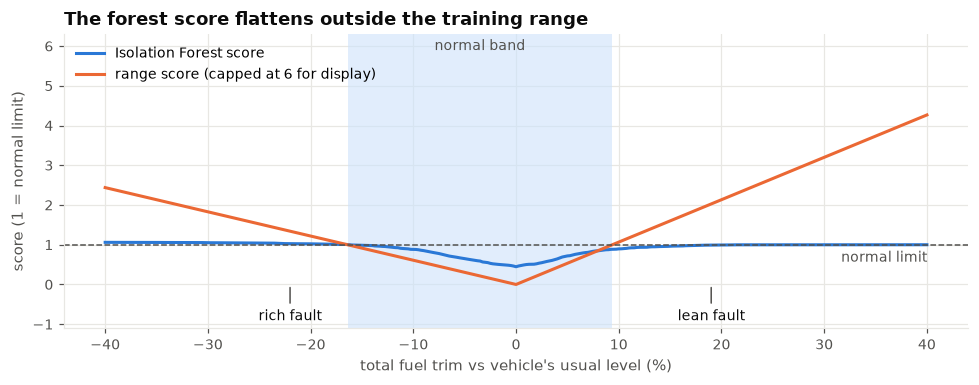

In [5]:
model, threshold, ranges = detector.models["fuel"], detector.thresholds["fuel"], detector.ranges["fuel"]
sweep = np.linspace(-40, 40, 321)
X = pd.DataFrame({"stft_rel_median": 0.4 * sweep, "ltft_rel_median": 0.6 * sweep, "total_trim_rel_median": sweep})
forest_score = -model.score_samples(X) / threshold
range_score = AnomalyDetector._range_score(X, ranges)

fig, ax = plt.subplots(figsize=(9, 3.6))
lo, hi = ranges.loc["total_trim_rel_median", ["low", "high"]]
ax.axvspan(lo, hi, color=BAND, alpha=0.6, lw=0)
ax.text((lo + hi) / 2, 5.9, "normal band", ha="center", color=TEXT_2, fontsize=9)
ax.plot(sweep, forest_score, color=BLUE, label="Isolation Forest score")
ax.plot(sweep, np.minimum(range_score, 6), color=ORANGE, label="range score (capped at 6 for display)")
ax.axhline(1, color=TEXT_2, lw=1, ls="--")
ax.text(40, 0.85, "normal limit", color=TEXT_2, fontsize=9, va="top", ha="right")
for x, name in [(-22, "rich fault"), (19, "lean fault")]:
    ax.annotate(name, (x, 0), xytext=(x, -0.9), ha="center", color=TEXT, fontsize=9,
                arrowprops=dict(arrowstyle="-", color=TEXT_2, lw=1))
ax.set_ylim(-1.1, 6.3)
ax.set_xlabel("total fuel trim vs vehicle's usual level (%)"); ax.set_ylabel("score (1 = normal limit)")
ax.set_title("The forest score flattens outside the training range")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
print(f"forest score at +20% trim: {forest_score[np.argmin(abs(sweep - 20))]:.2f}, "
      f"at +40%: {forest_score[-1]:.2f}  |  range score at +20%: {range_score[np.argmin(abs(sweep - 20))]:.2f}")

The forest score barely reaches the normal limit even for large shifts, so on its own it would miss most fuel faults. The range score keeps growing with distance from the normal band. Each detector therefore uses **the higher of the two**: the forest still catches unusual *combinations* of features, and the range score catches *extreme* values.

## 4. Ablation: forest only vs range only vs combined

The same trained detectors, scored three ways, with the same alarm rule (70% of the last 30 readings anomalous).

In [6]:
features = build_features(logs, detector.baseline)

def score_variant(mode):
    out = features[TRIP + ["time_ms"]].copy()
    group_cols = []
    for group, model in detector.models.items():
        cols = FEATURE_GROUPS[group]
        X = features[cols].dropna()
        s = pd.Series(np.nan, index=features.index)
        if len(X):
            forest = -model.score_samples(X) / detector.thresholds[group]
            rng = AnomalyDetector._range_score(X, detector.ranges[group])
            s[X.index] = {"forest only": forest, "range only": rng, "combined": np.maximum(forest, rng)}[mode]
        out[f"score_{group}"] = s
        group_cols.append(f"score_{group}")
    out["anomaly_score"] = out[group_cols].max(axis=1)
    has = out[group_cols].notna().any(axis=1)
    out["suspect_group"] = None
    out.loc[has, "suspect_group"] = out.loc[has, group_cols].idxmax(axis=1).str.removeprefix("score_")
    out["is_anomalous"] = out["anomaly_score"] > 1
    return out

def apply_alarm(out, window=30, ratio=0.7):
    recent = (out["is_anomalous"].astype(float).groupby([out["vehicle_id"], out["trip_id"]])
              .rolling(window, min_periods=window).mean().reset_index(level=[0, 1], drop=True))
    return out.assign(alarm=recent.reindex(out.index).fillna(0) >= ratio)

results, per_fault = [], {}
for mode in ["forest only", "range only", "combined"]:
    s = apply_alarm(score_variant(mode))
    m = row_metrics(s, logs)
    t = summarize(trip_results(s, labels)).set_index("fault")
    per_fault[mode] = t
    results.append({"scoring": mode, "precision": m["precision"], "recall": m["recall"], "F1": m["f1"],
                    "faulty trips detected": t.drop(NO_FAULT)["detection_rate"].mean(),
                    "normal trips with false alarm": t.loc[NO_FAULT, "false_alarm_rate"]})
ablation = pd.DataFrame(results).set_index("scoring")
ablation

,precision,recall,F1,faulty trips detected,normal trips with false alarm
scoring,,,,,
forest only,0.91,0.46,0.61,0.52,0.06
range only,0.93,0.80,0.86,0.90,0.07
combined,0.93,0.82,0.87,0.90,0.07


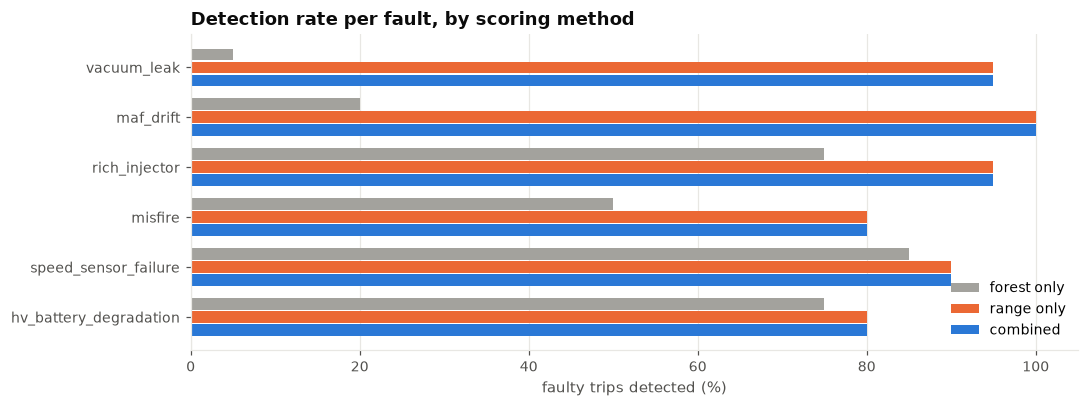

In [7]:
rates = pd.DataFrame({mode: t.drop(NO_FAULT)["detection_rate"] for mode, t in per_fault.items()}).reindex(FAULT_ORDER) * 100

fig, ax = plt.subplots(figsize=(10, 3.8))
width = 0.26
y = np.arange(len(rates))
for i, (mode, color) in enumerate(zip(rates.columns, [MUTED, ORANGE, BLUE])):
    ax.barh(y + (i - 1) * width, rates[mode], height=width - 0.03, color=color, label=mode)
ax.set_yticks(y, rates.index); ax.invert_yaxis()
ax.set_xlim(0, 105); ax.grid(axis="y", visible=False)
ax.set_xlabel("faulty trips detected (%)")
ax.set_title("Detection rate per fault, by scoring method")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()

- **Forest only** misses most vacuum-leak and MAF faults (F1 0.61): those are large shifts in one direction, exactly where the forest score flattens.
- **Range only** recovers them and does most of the work (F1 0.86).
- **Combined** adds a small further gain (F1 0.87, slightly higher recall at the same false alarm rate) by also catching unusual combinations. The forest earns its place, but the range score is the bigger contributor, which is an honest result worth knowing.

## 5. Results per fault (combined method)

In [8]:
final = per_fault["combined"]
table = final.drop(NO_FAULT).reindex(FAULT_ORDER)[["trips", "detection_rate", "detected_before_dtc", "median_warning_s", "top_suspect_group"]]
table.columns = ["trips", "detected", "detected before DTC", "median warning (s)", "suspect subsystem"]
print(f"normal trips with a false alarm: {final.loc[NO_FAULT, 'false_alarm_rate']:.0%}")
table

normal trips with a false alarm: 8%


,trips,detected,detected before DTC,median warning (s),suspect subsystem
fault,,,,,
vacuum_leak,20,0.95,0.45,-2.60,fuel
maf_drift,20,1.00,0.60,11.20,fuel
rich_injector,20,0.95,0.25,-20.80,fuel
misfire,20,0.80,0.20,-20.45,engine
speed_sensor_failure,20,0.90,0.50,8.85,speed
hv_battery_degradation,20,0.80,0.55,47.75,battery


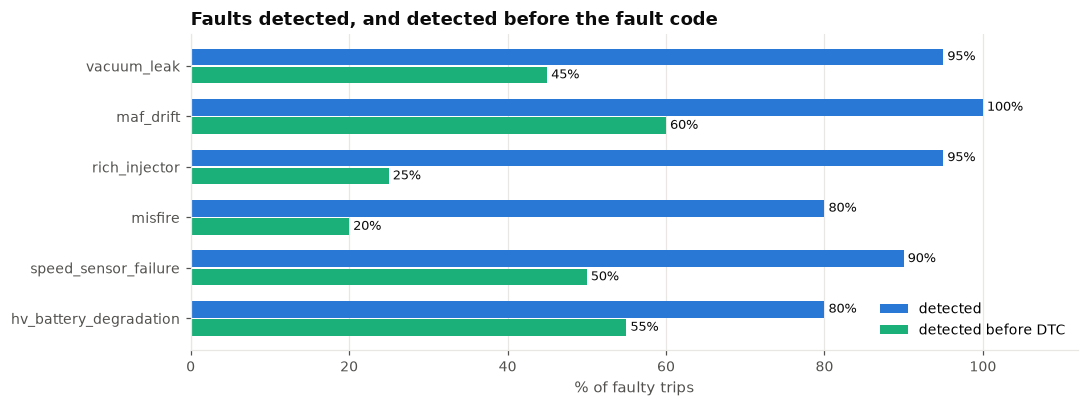

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))
plot = table.reindex(FAULT_ORDER)[["detected", "detected before DTC"]] * 100
y = np.arange(len(plot))
for i, (column, color) in enumerate(zip(plot.columns, [BLUE, AQUA])):
    bars = ax.barh(y + (i - 0.5) * 0.36, plot[column], height=0.33, color=color, label=column)
    for rect, v in zip(bars, plot[column]):
        ax.text(v, rect.get_y() + rect.get_height() / 2, f" {v:.0f}%", va="center", color=TEXT, fontsize=8.5)
ax.set_yticks(y, plot.index); ax.invert_yaxis()
ax.set_xlim(0, 112); ax.grid(axis="y", visible=False)
ax.set_xlabel("% of faulty trips")
ax.set_title("Faults detected, and detected before the fault code")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()

Every fault type is detected in most trips, and the alarm points to the subsystem that matches the fault (fuel faults → fuel, misfire → engine, and so on). MAF drift is flagged by the **fuel** detector, because the ECU's fuel correction reacts more clearly than the noisy airflow residual. The analyzer's root-cause step (step 5) then uses the airflow reading to tell MAF drift apart from a vacuum leak.

## 6. How early is the warning?

Warning time = DTC time − first alarm. Positive means the anomaly was flagged **before** the fault code.

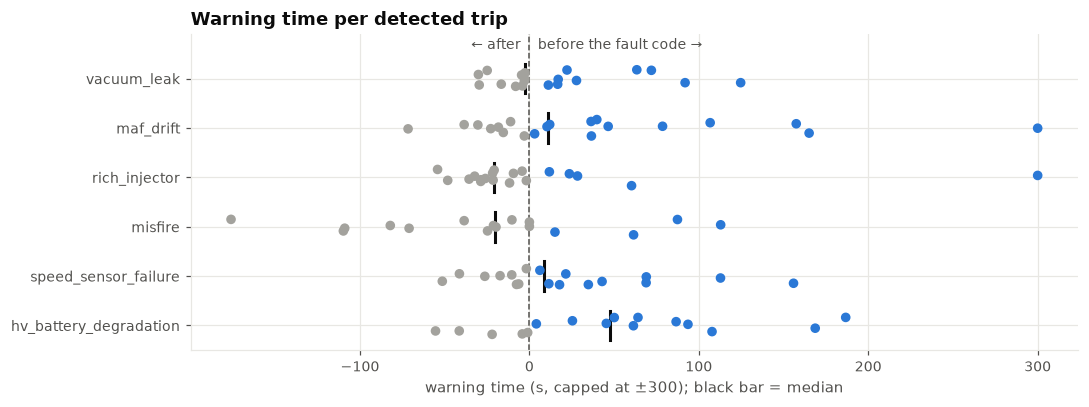

In [10]:
trips = trip_results(apply_alarm(score_variant("combined")), labels)
detected = trips[(trips["fault"] != NO_FAULT) & trips["alarm_raised"]]

fig, ax = plt.subplots(figsize=(10, 3.8))
for i, fault in enumerate(FAULT_ORDER):
    w = detected.loc[detected["fault"] == fault, "warning_before_dtc_s"].dropna()
    jitter = np.random.default_rng(i).uniform(-0.18, 0.18, len(w))
    ax.scatter(w.clip(-300, 300), i + jitter, s=28, color=np.where(w > 0, BLUE, MUTED), zorder=3)
    ax.plot([w.median()] * 2, [i - 0.3, i + 0.3], color=TEXT, lw=2)
ax.axvline(0, color=TEXT_2, lw=1, ls="--")
ax.text(5, -0.6, "before the fault code →", color=TEXT_2, fontsize=9)
ax.text(-5, -0.6, "← after", color=TEXT_2, fontsize=9, ha="right")
ax.set_yticks(range(len(FAULT_ORDER)), FAULT_ORDER); ax.invert_yaxis()
ax.set_ylim(len(FAULT_ORDER) - 0.5, -0.9)
ax.set_xlabel("warning time (s, capped at ±300); black bar = median")
ax.set_title("Warning time per detected trip")
plt.tight_layout()

Battery, MAF, speed and vacuum-leak faults are caught **before** the code in roughly half of the trips (median warning up to about 48 s for battery). Misfire and rich-injector faults are mostly caught just after the code: the fault has to grow large before it stands out from normal variation, and the DTC is set at about the same moment. Remember the window is short (median about 1.5 minutes from onset to DTC, notebook 2), so a warning of 30–60 seconds already uses a large part of it.

## 7. Alarm persistence trade-off

A single anomalous reading is not enough to raise an alarm; it has to persist. A longer, stricter rule means fewer false alarms but later and fewer detections.

,false alarms (normal trips),faulty trips detected,detected before DTC
rule,,,
50% of last 10,0.22,0.93,0.64
60% of last 20,0.11,0.93,0.56
70% of last 30,0.07,0.90,0.42
80% of last 40,0.06,0.87,0.37
80% of last 60,0.03,0.81,0.29
90% of last 90,0.03,0.70,0.19


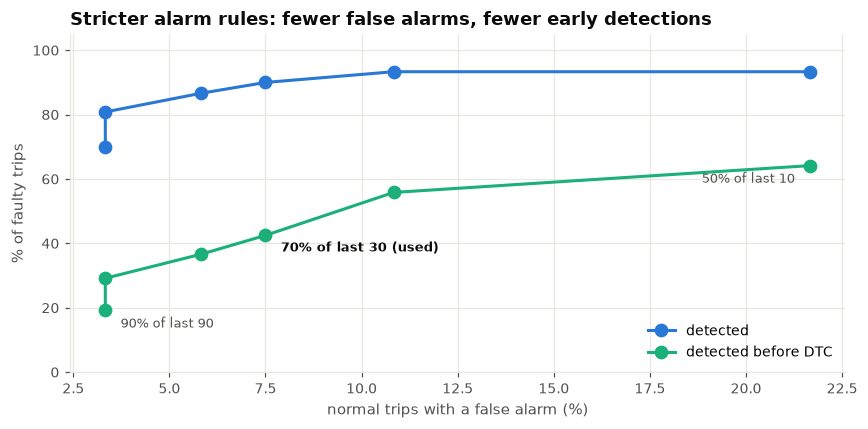

In [11]:
base = score_variant("combined")
grid = []
for window, ratio in [(10, 0.5), (20, 0.6), (30, 0.7), (40, 0.8), (60, 0.8), (90, 0.9)]:
    t = summarize(trip_results(apply_alarm(base, window, ratio), labels)).set_index("fault")
    grid.append({"rule": f"{ratio:.0%} of last {window}", "window": window,
                 "false alarms (normal trips)": t.loc[NO_FAULT, "false_alarm_rate"],
                 "faulty trips detected": t.drop(NO_FAULT)["detection_rate"].mean(),
                 "detected before DTC": t.drop(NO_FAULT)["detected_before_dtc"].mean()})
grid = pd.DataFrame(grid).set_index("rule")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(grid["false alarms (normal trips)"] * 100, grid["faulty trips detected"] * 100, color=BLUE, marker="o",
        markersize=8, label="detected")
ax.plot(grid["false alarms (normal trips)"] * 100, grid["detected before DTC"] * 100, color=AQUA, marker="o",
        markersize=8, label="detected before DTC")
for rule, offset, align in [("50% of last 10", (-10, -4), "right"), ("70% of last 30", (10, -4), "left"),
                            ("90% of last 90", (10, -4), "left")]:
    r = grid.loc[rule]
    chosen = r["window"] == 30
    ax.annotate(rule + (" (used)" if chosen else ""), (r["false alarms (normal trips)"] * 100, r["detected before DTC"] * 100),
                xytext=offset, textcoords="offset points", ha=align, va="top", fontsize=8.5,
                color=TEXT if chosen else TEXT_2, fontweight="bold" if chosen else "normal")
ax.set_xlabel("normal trips with a false alarm (%)"); ax.set_ylabel("% of faulty trips")
ax.set_ylim(0, 105)
ax.set_title("Stricter alarm rules: fewer false alarms, fewer early detections")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
grid.drop(columns="window")

The analyzer uses **70% of the last 30 readings**: 9 of 120 normal trips (7.5%) get a false alarm, while 90% of faulty trips are detected and 42% before the code. Looser rules catch faults earlier but alarm on more healthy trips; stricter rules miss the early part of the window.

> This setting was chosen on the same synthetic set it is evaluated on, so the results are somewhat optimistic. A separate validation set would give a fairer estimate.

## 8. One trip, step by step

A vacuum-leak trip: the fuel trim deviation, each detector's score, and when the alarm fires relative to fault onset and the DTC.

fault onset 3.92 min | first alarm 5.42 min | DTC 5.79 min -> warning 22 s before the code


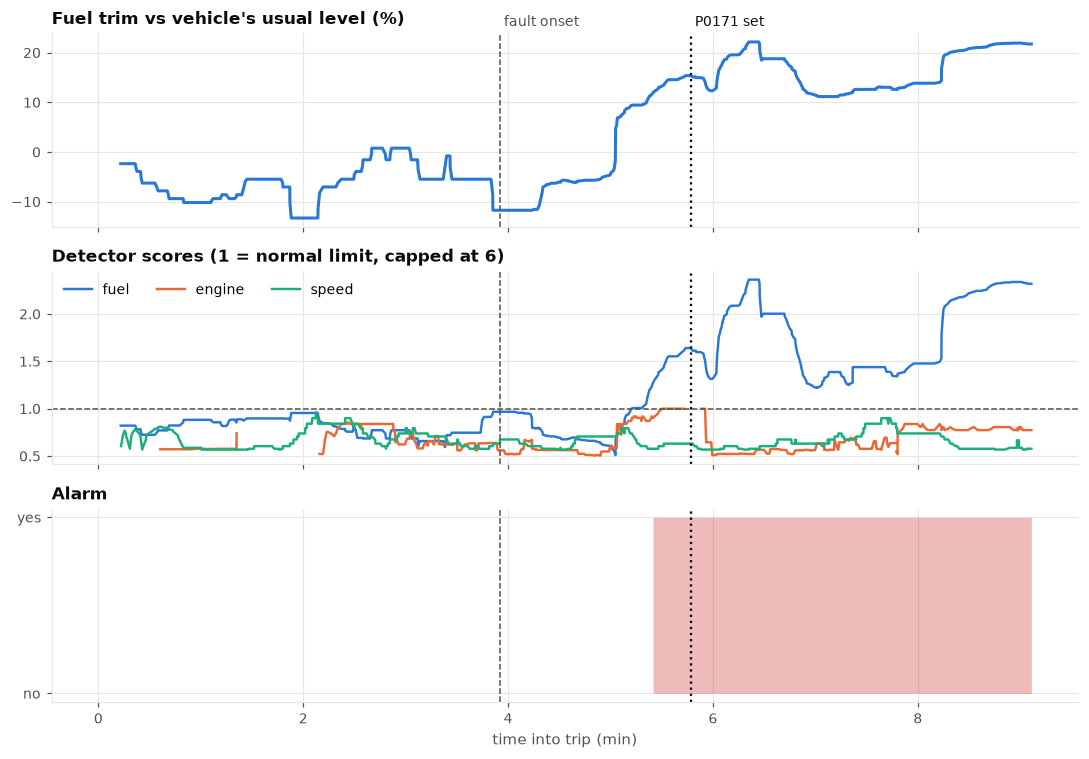

In [12]:
label = labels[labels["fault"] == "vacuum_leak"].iloc[3]
key = (label.vehicle_id, label.trip_id)
trip_scored = apply_alarm(base)
trip_scored = trip_scored[(trip_scored["vehicle_id"] == key[0]) & (trip_scored["trip_id"] == key[1])]
trip_feat = features.loc[trip_scored.index]
t = trip_scored["time_ms"] / 60_000
onset, dtc = label.onset_time_ms / 60_000, label.dtc_time_ms / 60_000
first_alarm = t[trip_scored["alarm"].to_numpy()].min()

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, trip_feat["total_trim_rel_median"], color=BLUE)
axes[0].set_title("Fuel trim vs vehicle's usual level (%)", fontsize=11)

for group, color in [("fuel", BLUE), ("engine", ORANGE), ("speed", AQUA)]:
    if f"score_{group}" in trip_scored:
        axes[1].plot(t, trip_scored[f"score_{group}"].clip(upper=6), color=color, lw=1.6, label=group)
axes[1].axhline(1, color=TEXT_2, lw=1, ls="--")
axes[1].set_title("Detector scores (1 = normal limit, capped at 6)", fontsize=11)
axes[1].legend(loc="upper left", ncol=3, fontsize=9)

axes[2].fill_between(t, trip_scored["alarm"].astype(int), step="post", color=FAULT_SHADE, alpha=0.35, lw=0)
axes[2].set_yticks([0, 1], ["no", "yes"])
axes[2].set_title("Alarm", fontsize=11)
axes[2].set_xlabel("time into trip (min)")

for ax in axes:
    ax.axvline(onset, color=TEXT_2, lw=1, ls="--")
    ax.axvline(dtc, color=TEXT, lw=1.5, ls=":")
axes[0].text(onset, 1.02, " fault onset", transform=axes[0].get_xaxis_transform(), color=TEXT_2, fontsize=9, va="bottom")
axes[0].text(dtc, 1.02, f" {label.dtc_codes} set", transform=axes[0].get_xaxis_transform(), color=TEXT, fontsize=9, va="bottom")
plt.tight_layout()
print(f"fault onset {onset:.2f} min | first alarm {first_alarm:.2f} min | DTC {dtc:.2f} min "
      f"-> warning {60 * (dtc - first_alarm):.0f} s before the code")

The fuel trim starts drifting at onset, the fuel detector's score climbs past the limit while the other detectors stay low, the alarm fires once the anomaly has persisted, and only then is the fault code set.

## 9. Limitations and summary

**Limitations**
- Faults are simulated (notebook 2), so these numbers show that the method works on realistic signal changes, not how it performs on real failures.
- The alarm rule was tuned on the evaluation set.
- Training used one week, in which only about 15% of trips record fuel trims (notebook 1); more weeks should improve the fuel detector.
- About 1 reading per second limits misfire detection.
- Most false alarms come from the battery detector, whose linear voltage model ignores temperature.

**Summary**

| | |
|---|---|
| Model | One detector per subsystem, trained on normal driving only |
| Scoring | max(Isolation Forest, range score), 1.0 = edge of normal |
| Why combined | The forest score flattens outside the training range; the range score catches large shifts |
| Alarm | 70% of the last 30 readings anomalous |
| Result | 80–100% of trips detected per fault, right subsystem, 7.5% false alarms on normal trips, F1 0.87 |
| Combined vs forest only | F1 0.61 → 0.87; the range score does most of the work |
| Early warning | Before the code in about half of battery, MAF, speed and vacuum-leak trips; misfire and rich faults mostly just after |

**Next:** `04_diagnosis_demo.ipynb`, from anomaly to root cause, health score and report.